# Data Profiling
## Análisis Financiero de las 10.000 Empresas Más Grandes de Colombia

### Objetivo

Realizar un perfilamiento de los datos para comprender la estructura del conjunto de datos, evaluar su calidad e identificar posibles problemas antes de iniciar el proceso ETL.

---

### Fuente de datos

Superintendencia de Sociedades

Base de las 10.000 empresas más grandes de Colombia

Corte 2025

---

### Herramientas

- Python
- Pandas
- NumPy
- Matplotlib

In [1]:
# Importación de librerías


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de visualización

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [13]:
# 1. Carga de datos

# Ruta del archivo

ruta = "/content/Base_10000_empresas_2026.xlsx"

# Lectura

df = pd.read_excel(ruta)

print("Base cargada correctamente.")

Base cargada correctamente.


In [14]:
df.head()

,RANKING 2025,NIT,RAZON SOCIAL,SUPERVISOR,REGIÓN,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES 2025*,GANANCIA (PÉRDIDA) 2025,TOTAL ACTIVOS 2025,TOTAL PASIVOS 2025,TOTAL PATRIMONIO 2025,INGRESOS OPERACIONALES 2024*,GANANCIA (PÉRDIDA) 2024,TOTAL ACTIVOS 2024,TOTAL PASIVOS 2024,TOTAL PATRIMONIO 2024,RANKING 2025.1
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
1,2,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,26395418332,628485892,8112318463,4699968205,3412350258,2.475201e+10,5.307560e+08,7.971212e+09,4.621825e+09,3.349387e+09,2
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
3,4,900276962,D1 S A S,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,21606607933,418933423,6939606162,6724638908,214967254,1.943940e+10,3.732099e+08,6.321816e+09,6.104116e+09,2.177000e+08,4
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5


In [15]:
# 2. Dimensiones del conjunto de datos

filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de columnas: {columnas}")

Número de registros: 10000
Número de columnas: 20


###Hallazgos

- Contiene 10.000 registros
- Contiene 20 variables

In [16]:
# 3. Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   RANKING 2025                  10000 non-null  int64  
 1   NIT                           10000 non-null  int64  
 2   RAZON SOCIAL                  10000 non-null  object 
 3   SUPERVISOR                    10000 non-null  object 
 4   REGIÓN                        10000 non-null  object 
 5   DEPARTAMENTO DOMICILIO        10000 non-null  object 
 6   CIUDAD DOMICILIO              10000 non-null  object 
 7   CIIU                          10000 non-null  object 
 8   MACROSECTOR                   10000 non-null  object 
 9   INGRESOS OPERACIONALES 2025*  10000 non-null  int64  
 10  GANANCIA (PÉRDIDA) 2025       10000 non-null  int64  
 11  TOTAL ACTIVOS 2025            10000 non-null  int64  
 12  TOTAL PASIVOS 2025            10000 non-null  int64  
 13  TO

###Hallazgos

- Hay registros que no cuentan con información financiera del año 2024
- Las variables de 2024 aparecen como float64 porque contienen valores nulos

In [26]:
# 4. Inspeccionar nombre de columnas

df.columns.tolist()

['RANKING 2025',
 'NIT',
 'RAZON SOCIAL',
 'SUPERVISOR',
 'REGIÓN',
 'DEPARTAMENTO DOMICILIO',
 'CIUDAD DOMICILIO',
 'CIIU',
 'MACROSECTOR',
 'INGRESOS OPERACIONALES 2025*',
 'GANANCIA (PÉRDIDA) 2025',
 'TOTAL ACTIVOS 2025',
 'TOTAL PASIVOS 2025',
 'TOTAL PATRIMONIO 2025',
 'INGRESOS OPERACIONALES 2024*',
 'GANANCIA (PÉRDIDA) 2024',
 'TOTAL ACTIVOS 2024',
 'TOTAL PASIVOS 2024',
 'TOTAL PATRIMONIO 2024',
 'RANKING 2025.1']

### Hallazgos

- Se identificó una columna duplicada (`RANKING 2025.1`).
- Dos columnas presentan un asterisco (`*`) en el nombre.
- Existen caracteres especiales y espacios que serán estandarizados durante el ETL.

In [29]:
# 5. Valores nulos

nulos = df.isnull().sum()

nulos = nulos[nulos > 0]

nulos.sort_values(ascending=False)

,0
TOTAL PASIVOS 2024,55
TOTAL PATRIMONIO 2024,53
TOTAL ACTIVOS 2024,53
INGRESOS OPERACIONALES 2024*,1
GANANCIA (PÉRDIDA) 2024,1


In [19]:
# 6. Registros duplicados

duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


In [20]:
# 7. Estadísticas descriptivas

df.describe().T

,count,mean,std,min,25%,50%,75%,max
RANKING 2025,10000.0,5.000500e+03,2.886896e+03,1.000000e+00,2.500750e+03,5000.5,7.500250e+03,1.000000e+04
NIT,10000.0,8.678463e+08,4.007160e+07,8.000003e+08,8.300512e+08,891224132.0,9.005609e+08,9.019666e+08
INGRESOS OPERACIONALES 2025*,10000.0,1.853802e+08,1.247754e+09,2.125605e+07,3.191299e+07,51954860.0,1.136822e+08,1.005907e+11
GANANCIA (PÉRDIDA) 2025,10000.0,1.386655e+07,1.581161e+08,-1.983319e+09,4.666448e+05,1750991.0,5.360869e+06,9.028765e+09
TOTAL ACTIVOS 2025,10000.0,2.560405e+08,2.596320e+09,3.312980e+05,1.937913e+07,40623242.0,1.066755e+08,1.981109e+11
TOTAL PASIVOS 2025,10000.0,1.376665e+08,1.669713e+09,0.000000e+00,8.557942e+06,19634044.5,5.312068e+07,1.143506e+11
TOTAL PATRIMONIO 2025,10000.0,1.183740e+08,1.136198e+09,-1.431150e+09,6.809172e+06,16656508.5,4.498582e+07,8.376026e+10
INGRESOS OPERACIONALES 2024*,9999.0,1.755748e+08,1.351397e+09,0.000000e+00,2.833543e+07,47176902.0,1.047237e+08,1.139233e+11
GANANCIA (PÉRDIDA) 2024,9999.0,1.256449e+07,2.018530e+08,-1.342691e+09,3.219695e+05,1428454.0,4.488644e+06,1.493470e+10
TOTAL ACTIVOS 2024,9947.0,2.530935e+08,2.749484e+09,0.000000e+00,1.752520e+07,37737614.0,9.967274e+07,2.142410e+11


In [21]:
# 8. Variables categóricas

df.describe(include="object").T

,count,unique,top,freq
RAZON SOCIAL,10000,9998,NEWREST SERVICES COLOMBIA S.A.S,2
SUPERVISOR,10000,5,SUPERSOCIEDADES,8916
REGIÓN,10000,9,BOGOTÁ-CUNDINAMARCA,4806
DEPARTAMENTO DOMICILIO,10000,37,DISTRITO CAPITAL DE BOGOTÁ,4001
CIUDAD DOMICILIO,10000,432,BOGOTA D.C.,3587
CIIU,10000,375,G4631 - Comercio al por mayor de productos ali...,314
MACROSECTOR,10000,6,COMERCIO,3718


In [22]:
# 9. Valores únicos por columna

df.nunique().sort_values()

,0
SUPERVISOR,5
MACROSECTOR,6
REGIÓN,9
DEPARTAMENTO DOMICILIO,37
CIIU,375
CIUDAD DOMICILIO,432
TOTAL PASIVOS 2024,9937
TOTAL PATRIMONIO 2024,9940
TOTAL ACTIVOS 2024,9943
GANANCIA (PÉRDIDA) 2024,9969


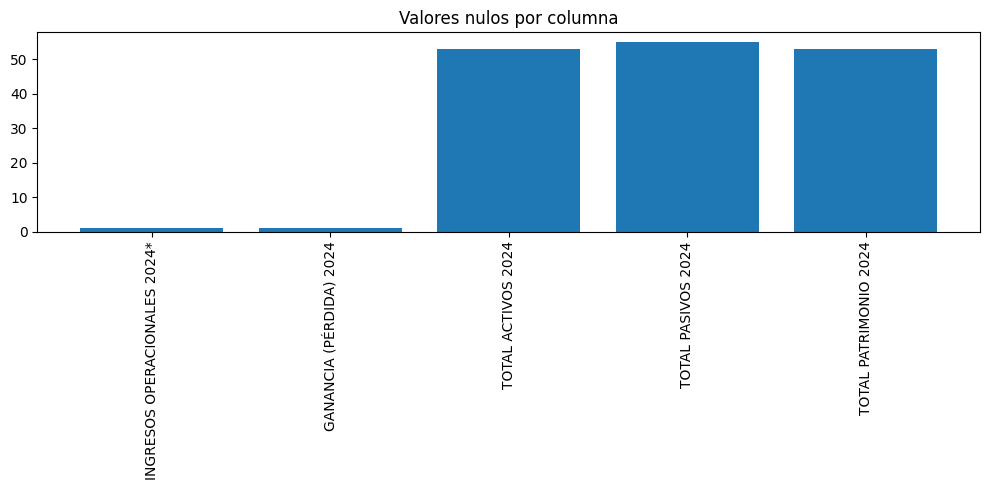

In [23]:
# 10. Distribución de valores nulos

nulos = df.isnull().sum()

nulos = nulos[nulos > 0]

plt.figure(figsize=(10,5))

plt.bar(nulos.index, nulos.values)

plt.xticks(rotation=90)

plt.title("Valores nulos por columna")

plt.tight_layout()

plt.show()

In [24]:
# 11. Variables numéricas

variables_numericas = df.select_dtypes(include=np.number).columns

variables_numericas

Index(['RANKING 2025', 'NIT', 'INGRESOS OPERACIONALES 2025*',
       'GANANCIA (PÉRDIDA) 2025', 'TOTAL ACTIVOS 2025', 'TOTAL PASIVOS 2025',
       'TOTAL PATRIMONIO 2025', 'INGRESOS OPERACIONALES 2024*',
       'GANANCIA (PÉRDIDA) 2024', 'TOTAL ACTIVOS 2024', 'TOTAL PASIVOS 2024',
       'TOTAL PATRIMONIO 2024', 'RANKING 2025.1'],
      dtype='object')

In [25]:
# 12. Variables categóricas

variables_categoricas = df.select_dtypes(exclude=np.number).columns

variables_categoricas

Index(['RAZON SOCIAL', 'SUPERVISOR', 'REGIÓN', 'DEPARTAMENTO DOMICILIO',
       'CIUDAD DOMICILIO', 'CIIU', 'MACROSECTOR'],
      dtype='object')

# 13. Conclusiones del perfilamiento

En esta sección se documentarán los principales hallazgos del análisis.

- Número de registros: 10.000 registros
- Número de columnas: 20 columnas
- Variables numéricas: 'RANKING 2025', 'NIT', 'INGRESOS OPERACIONALES 2025*',
       'GANANCIA (PÉRDIDA) 2025', 'TOTAL ACTIVOS 2025', 'TOTAL PASIVOS 2025',
       'TOTAL PATRIMONIO 2025', 'INGRESOS OPERACIONALES 2024*',
       'GANANCIA (PÉRDIDA) 2024', 'TOTAL ACTIVOS 2024', 'TOTAL PASIVOS 2024',
       'TOTAL PATRIMONIO 2024', 'RANKING 2025.1'
- Variables categóricas: 'RAZON SOCIAL', 'SUPERVISOR', 'REGIÓN', 'DEPARTAMENTO DOMICILIO',
       'CIUDAD DOMICILIO', 'CIIU', 'MACROSECTOR'
- Valores nulos encontrados: TOTAL PASIVOS 2024	(55),
TOTAL PATRIMONIO 2024	(53),
TOTAL ACTIVOS 2024	(53),
INGRESOS OPERACIONALES 2024*	(1),
GANANCIA (PÉRDIDA) 2024	(1).


- Duplicados: 0